# Modeling 


In [6]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import preprocess
import explore
import model

In [7]:
# Load
df_im, df_cl = explore.load_data()

# Clean immunological (outliers removed)
df_im, _, df_im_vis = preprocess.clean_im(df_im)
df_im_vis = preprocess.remove_outlier_observations(df_im_vis)

# Clean clinical
df_cl_vis = preprocess.clean_cl(df_cl)

# Modeling copy  drop high-NaN / pain / radiation / leaky columns
df_cl_mod = df_cl_vis.copy()
df_cl_mod = preprocess.drop_high_nan_columns(
    df_cl_mod, threshold=0.25,
    exclude_cols=['Patient', 'Timepoint', 'date', 'measurement_timepoint'],
    check_per_timepoint=True,
)
for attr in ['CL_PAIN_QUESTIONNAIRE_COLS', 'CL_RADIATION_EQUIPMENT_COLS', 'CL_EXTRA_MODEL_DROP_COLS']:
    df_cl_mod = df_cl_mod.drop(
        columns=[c for c in df_cl_mod.columns if c in set(getattr(preprocess, attr))],
        errors='ignore')
df_cl_mod = df_cl_mod.drop(
    columns=[c for c in df_cl_mod.columns
             if any(p in c for p in preprocess.CL_LEAKY_PATTERNS)],
    errors='ignore')

print(f"df_im_vis : {df_im_vis.shape}")
print(f"df_cl_mod : {df_cl_mod.shape}")

  [1] Dropping excluded columns and renaming Messdatum → Date
  Dropping 44 columns.
  [2] Dropping known empty rows
  Dropping 7 rows at index: [823, 824, 825, 826, 827, 828, 78]
  Patient IDs in dropped rows: [30.0]
  Unique patients remaining: 264
  [3] Replacing German NaN markers
  Neu_CD25+: replaced 161 null markers
  BAS_CD25+: replaced 18 null markers
  Mo_CD25+: replaced 109 null markers
  T_CD25hi: replaced 5 null markers
  TC_CD25hi: replaced 790 null markers
  TH_CD25hi: replaced 5 null markers
  B_CD25+: replaced 7 null markers
  B_CD25hi: replaced 810 null markers
  NK_CD25+: replaced 150 null markers
  Neu_HLADR+: replaced 27 null markers
  Eos_HLADR+: replaced 567 null markers
  Mo_HLADRhi: replaced 4 null markers
  Mo2_HLADR+: replaced 192 null markers
  Mo3_HLADR+: replaced 73 null markers
  Mo1_HLADRhi: replaced 11 null markers
  Mo2_HLADRhi: replaced 230 null markers
  Mo3_HLADRhi: replaced 90 null markers
  TC_HLADR+: replaced 7 null markers
  T_HLADRhi: replaced 


  Targets: 'pain_scale'  (T1 → T2)
  Patients with T1 values    : 189
  Patients with T2 values    : 176
  Eligible (non-NaN both, n)    : 142
  Eligible patient IDs          : [1, 5, 6, 10, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 29, 34, 58, 72, 76, 91, 92, 93, 94, 101, 104, 105, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 118, 119, 120, 121, 122, 123, 125, 126, 127, 128, 129, 131, 132, 133, 134, 135, 136, 137, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 151, 153, 154, 155, 157, 158, 159, 161, 163, 164, 170, 171, 172, 173, 174, 175, 176, 177, 178, 180, 181, 182, 183, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 199, 201, 202, 203, 205, 206, 207, 208, 209, 210, 212, 214, 215, 218, 220, 221, 222, 223, 224, 225, 226, 229, 230, 232, 234, 237, 239, 240, 245, 246, 248, 250, 253, 256, 258, 259, 269, 270, 271, 272, 273]

  Target distributions:
    pain_reduction                              mean=1.349  std=2.042  [-4.000, 7.100]
    pain_reduction_pct   

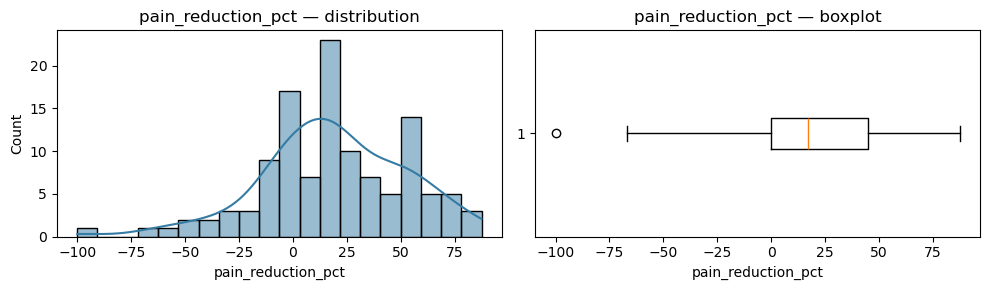

  Top 10 Pearson |r| with pain_reduction_pct:
pain_reduction             0.934507
TC eff_PD1+_t1_minus_t2    0.185795
DPT_t1_minus_t2            0.178147
TC_PD1+_t1_minus_t2        0.171555
TC CM_PD1+_t1_minus_t2     0.161279
TH_t1_minus_t2             0.155935
Basophils.1_t1_minus_t2    0.153092
T cells_t1_minus_t2        0.152862
Monocytes_t1_minus_t2      0.151674
Mo1_t1_minus_t2            0.150820

───────────────────────────────────────────────────────
  pain_under_load_reduction  (n=117, features=95)
  mean=0.52  std=0.75  min=-1.00  max=3.00
  skew=1.02  kurt=1.00  zeros=54.7%


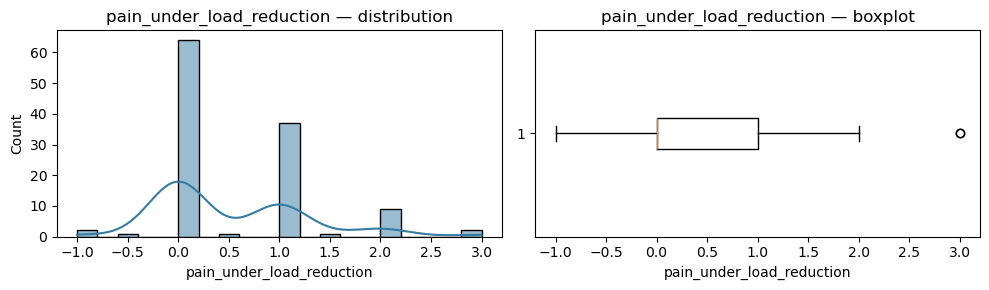

  Top 10 Pearson |r| with pain_under_load_reduction:
pain_under_load_reduction_pct    0.982386
NK_CD25+_t1_minus_t2             0.244959
BAS_CD25+_t1_minus_t2            0.243665
Mo1_t1_minus_t2                  0.210402
Monocytes_t1_minus_t2            0.207577
NK2_t1_minus_t2                  0.193114
Neu_HLADR+_t1_minus_t2           0.187514
B_CD25+_t1_minus_t2              0.160346
DNT_t1_minus_t2                  0.142525
TC CM_PD1+_t1_minus_t2           0.141425


In [8]:
# Construct regression targets (T1 → T2)
pain_targets = model.construct_datasets_targets(df_cl_vis, 'pain_scale',      [1, 2])
targets_ul   = model.construct_datasets_targets(df_cl_vis, 'pain_under_load', [1, 2])

# Build combined (immunological T1–T2 diffs + clinical) datasets
model_datasets = {}
for tgt, tdf in {'pain_reduction': pain_targets, 'pain_under_load_reduction': targets_ul}.items():
    _, df_comb = model.create_model_datasets(df_cl_mod, df_im_vis, tdf, timepoints=[1, 2])
    model_datasets[tgt] = df_comb

# Target distributions + Pearson correlations
id_like = ['Patient', 'Timepoint', 'Date', 'date', 'measurement_timepoint']

for tgt, df in model_datasets.items():
    for col in ['pain_reduction_pct', 'pain_under_load_reduction']:
        if col not in df.columns:
            continue
        y = df[col].dropna()
        print(f"\n{'─'*55}")
        print(f"  {col}  (n={len(y)}, features={df.shape[1]})")
        print(f"  mean={y.mean():.2f}  std={y.std():.2f}  min={y.min():.2f}  max={y.max():.2f}")
        print(f"  skew={y.skew():.2f}  kurt={y.kurt():.2f}  zeros={( y==0).mean()*100:.1f}%")

        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        sns.histplot(y, kde=True, ax=axes[0], color=sns.color_palette('mako', 1)[0], bins=20)
        axes[0].set_title(f'{col} — distribution'); axes[0].set_xlabel(col)
        axes[1].boxplot(y, vert=False)
        axes[1].set_title(f'{col} — boxplot'); axes[1].set_xlabel(col)
        plt.tight_layout(); plt.show()

        num_cols = [c for c in df.select_dtypes(include='number').columns if c not in id_like]
        corrs = df[num_cols].corrwith(df[col]).drop(index=col, errors='ignore')
        corrs = corrs.dropna().abs().sort_values(ascending=False).head(10)
        print(f"  Top 10 Pearson |r| with {col}:")
        print(corrs.to_string())

## Baseline CatBoost

In [10]:
for tgt, df in [('pain_reduction_pct',       model_datasets['pain_reduction']),
                ('pain_under_load_reduction', model_datasets['pain_under_load_reduction'])]:
    res, mdl, X, ypred = model.run_catboost_regressor(df, tgt, f'Baseline — {tgt}')
    y_true = df[tgt].dropna().reset_index(drop=True)
    


  CatBoost Regressor Baseline — Baseline — pain_reduction_pct
  Target : pain_reduction_pct
  Samples: 118,  Features: 92
  CV     : 5-fold × 5 repeats = 25 fits
  Fold  1: MAE=36.212  MSE=1930.325  RMSE=43.935  R²=-0.236
  Fold  2: MAE=24.233  MSE=809.988  RMSE=28.460  R²=-0.116
  Fold  3: MAE=20.162  MSE=687.303  RMSE=26.216  R²=0.096
  Fold  4: MAE=32.881  MSE=1932.957  RMSE=43.965  R²=-0.564
  Fold  5: MAE=23.732  MSE=1007.335  RMSE=31.739  R²=-0.345
  Fold  6: MAE=31.925  MSE=1850.241  RMSE=43.014  R²=-0.229
  Fold  7: MAE=30.857  MSE=1530.547  RMSE=39.122  R²=-0.222
  Fold  8: MAE=27.827  MSE=1177.688  RMSE=34.317  R²=-0.140
  Fold  9: MAE=23.729  MSE=812.675  RMSE=28.507  R²=0.071
  Fold 10: MAE=23.312  MSE=993.601  RMSE=31.521  R²=-0.458
  Fold 11: MAE=25.218  MSE=935.436  RMSE=30.585  R²=-0.170
  Fold 12: MAE=22.203  MSE=832.205  RMSE=28.848  R²=-0.017
  Fold 13: MAE=39.454  MSE=2327.732  RMSE=48.247  R²=-0.311
  Fold 14: MAE=24.868  MSE=1137.101  RMSE=33.721  R²=-0.245
  Fol

## CatBoost + RENT (Nested CV + Optuna)

In [ ]:
cb_rent_pct_results, cb_rent_pct_params, cb_rent_pct_model, cb_rent_pct_X, cb_rent_pct_ypred, cb_rent_pct_features = \
    model.run_advanced_catboost_rent(model_datasets['pain_reduction'], target_col='pain_reduction_pct')

#model.plot_shap_regressor(cb_rent_pct_model, cb_rent_pct_X, 'CatBoost+RENT — pain_reduction_pct')
#model.plot_prediction_heatmap(
 #   model_datasets['pain_reduction']['pain_reduction_pct'].dropna().reset_index(drop=True),
  #  cb_rent_pct_ypred.dropna(), 'CatBoost+RENT — pain_reduction_pct')

In [ ]:
cb_rent_ul_results, cb_rent_ul_params, cb_rent_ul_model, cb_rent_ul_X, cb_rent_ul_ypred, cb_rent_ul_features = \
    model.run_advanced_catboost_rent(model_datasets['pain_under_load_reduction'], target_col='pain_under_load_reduction')

#model.plot_shap_regressor(cb_rent_ul_model, cb_rent_ul_X, 'CatBoost+RENT — pain_under_load_reduction')
#model.plot_prediction_heatmap(
 #   model_datasets['pain_under_load_reduction']['pain_under_load_reduction'].dropna().reset_index(drop=True),
  #  cb_rent_ul_ypred.dropna(), 'CatBoost+RENT — pain_under_load_reduction')

## ElasticNet + RENT (Nested CV + Optuna)

In [ ]:
en_rent_pct_results, en_rent_pct_params, en_rent_pct_model, en_rent_pct_X, en_rent_pct_ypred, en_rent_pct_features = \
    model.run_advanced_elasticnet_rent(model_datasets['pain_reduction'], target_col='pain_reduction_pct')

#model.plot_elasticnet_coefficients(en_rent_pct_model, list(en_rent_pct_X.columns), 'ElasticNet+RENT — pain_reduction_pct')
#model.plot_prediction_heatmap(
 #   model_datasets['pain_reduction']['pain_reduction_pct'].dropna().reset_index(drop=True),
  #  en_rent_pct_ypred.dropna(), 'ElasticNet+RENT — pain_reduction_pct')

In [ ]:
en_rent_ul_results, en_rent_ul_params, en_rent_ul_model, en_rent_ul_X, en_rent_ul_ypred, en_rent_ul_features = \
    model.run_advanced_elasticnet_rent(model_datasets['pain_under_load_reduction'], target_col='pain_under_load_reduction')

#model.plot_elasticnet_coefficients(en_rent_ul_model, list(en_rent_ul_X.columns), 'ElasticNet+RENT — pain_under_load_reduction')
#model.plot_prediction_heatmap(
 #   model_datasets['pain_under_load_reduction']['pain_under_load_reduction'].dropna().reset_index(drop=True),
  #  en_rent_ul_ypred.dropna(), 'ElasticNet+RENT — pain_under_load_reduction')

## PLS + RENT (Nested CV + Optuna)

In [ ]:
pls_rent_pct_results, pls_rent_pct_params, pls_rent_pct_model, pls_rent_pct_X, pls_rent_pct_ypred, pls_rent_pct_features = \
    model.run_advanced_pls_rent(model_datasets['pain_reduction'], target_col='pain_reduction_pct')

#model.plot_pls_coefficients(pls_rent_pct_model, list(pls_rent_pct_X.columns), 'PLS+RENT — pain_reduction_pct')
#model.plot_prediction_heatmap(
 #   model_datasets['pain_reduction']['pain_reduction_pct'].dropna().reset_index(drop=True),
  #  pls_rent_pct_ypred.dropna(), 'PLS+RENT — pain_reduction_pct')


In [ ]:

pls_rent_ul_results, pls_rent_ul_params, pls_rent_ul_model, pls_rent_ul_X, pls_rent_ul_ypred, pls_rent_ul_features = \
    model.run_advanced_pls_rent(model_datasets['pain_under_load_reduction'], target_col='pain_under_load_reduction')

#model.plot_pls_coefficients(pls_rent_ul_model, list(pls_rent_ul_X.columns), 'PLS+RENT — pain_under_load_reduction')
#model.plot_prediction_heatmap(
 #   model_datasets['pain_under_load_reduction']['pain_under_load_reduction'].dropna().reset_index(drop=True),
  #  pls_rent_ul_ypred.dropna(), 'PLS+RENT — pain_under_load_reduction')